In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split

In [ ]:
#from google.colab import drive
#drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Big Datasets/Churn_Modelling.csv")

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.shape

(10000, 14)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [11]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [12]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [13]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [14]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [17]:
x = df.drop(['Exited'], axis=1)
y = df['Exited']

In [18]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42, test_size=0.2)

In [19]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.fit_transform(xtest)

# Deep Learning Model Building

In [31]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

In [44]:
model = Sequential()

model.add(Dense(11, activation='relu', input_dim=11)) #input layer
model.add(Dense(11, activation='relu'))  #Hidden Layer
model.add(Dense(1, activation='sigmoid'))  #Hidden Layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [47]:
history = model.fit(xtrain_scaled, ytrain, epochs=100, validation_split=0.2)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7564 - loss: 0.5300 - val_accuracy: 0.7981 - val_loss: 0.4635
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7947 - loss: 0.4635 - val_accuracy: 0.8031 - val_loss: 0.4391
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7981 - loss: 0.4432 - val_accuracy: 0.8112 - val_loss: 0.4231
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8075 - loss: 0.4257 - val_accuracy: 0.8281 - val_loss: 0.4075
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8225 - loss: 0.4081 - val_accuracy: 0.8394 - val_loss: 0.3924
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8381 - loss: 0.3905 - val_accuracy: 0.8506 - val_loss: 0.3797
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8481 - loss: 0.3761 - val_accuracy: 0.8525 - val_loss: 0.3724
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8511 - loss: 0.3672 - val_accuracy: 0.8550

In [37]:
model.layers[0].get_weights()

[array([[-0.02508032, -0.07778585, -0.05971653, -0.31489435,  0.15330765,
          0.16274396, -0.08891489, -0.15155128,  0.09185593, -0.10914106,
          0.16721644],
        [-0.19544978,  0.2376881 , -0.8299569 , -0.314988  , -0.5773876 ,
          0.1558015 ,  0.2009462 ,  0.1888329 ,  0.2547235 ,  0.71223253,
          0.3666406 ],
        [-0.34787783,  0.04537835,  0.07146598, -0.07049196, -0.0789184 ,
          0.27436587, -0.01236922, -0.07271273, -0.30517814,  0.22778484,
          0.15405132],
        [ 0.47182822, -0.4062219 , -0.12794861,  0.2181119 ,  0.05929014,
         -0.6331111 ,  1.0033029 , -0.00912127, -0.63294953, -0.35438278,
         -0.43735898],
        [-0.4808468 , -1.1006181 ,  0.10371309,  0.0319269 ,  0.25029927,
         -0.20450507, -0.24396695,  1.4450276 ,  0.06420345,  0.1321887 ,
          0.7869268 ],
        [-0.08461691, -0.24035515, -0.09694918,  0.6522589 , -0.24805242,
         -0.13437392, -0.25937486, -0.20545058, -0.34458628,  0.1100929

In [38]:
model.layers[1].get_weights()

[array([[ 0.4418551 ,  0.3073301 ,  0.46434155,  0.38973847, -0.29966184,
         -0.20037939,  0.2462875 ,  0.5849934 ,  0.3303494 ,  0.56850237,
          0.63543427],
        [-0.35575828,  0.823303  ,  0.11926674, -0.3741027 ,  0.61232096,
          0.12363091, -0.2022905 ,  0.02196165, -0.16559099,  0.2618662 ,
          0.5119513 ],
        [ 0.6521963 , -0.346394  ,  0.6157167 ,  0.20336232, -0.7086059 ,
         -1.4803274 ,  0.32524833, -0.16020174,  0.11968923, -0.15759182,
         -1.201515  ],
        [-0.19925551,  0.02341523,  0.19400673,  0.17875223, -0.14568706,
         -0.66700715, -0.42766458, -0.13216029, -0.07613421,  0.6915177 ,
         -0.5400177 ],
        [ 0.37484282, -0.32511735, -0.05856788,  0.03141696, -0.0398114 ,
         -1.2668582 ,  0.04953979,  0.3149018 ,  0.20592758,  0.29178   ,
         -0.12795568],
        [ 0.27610317,  0.58471423,  0.5745624 , -0.57334757, -0.18831585,
         -0.30037832, -0.51662785, -0.65412366, -0.33529526,  0.1474138

In [39]:
model.layers[2].get_weights()

[array([[-0.78734946],
        [ 1.1017067 ],
        [-0.24950862],
        [ 0.70413697],
        [ 1.3057778 ],
        [-2.0114489 ],
        [ 1.0131556 ],
        [ 0.30562133],
        [-0.24549168],
        [-0.43091306],
        [ 0.51103926]], dtype=float32),
 array([-0.25129357], dtype=float32)]

In [40]:
y_log = model.predict(xtest_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [41]:
y_pred = np.where(y_log>0.5, 1, 0)

In [42]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [43]:
accuracy_score(ytest, y_pred)

0.8625

In [48]:
import matplotlib.pyplot as plt

In [50]:
history.history

{'accuracy': [0.7564062476158142,
  0.7946875095367432,
  0.7981250286102295,
  0.8075000047683716,
  0.8224999904632568,
  0.8381249904632568,
  0.8481249809265137,
  0.8510937690734863,
  0.8540624976158142,
  0.8526562452316284,
  0.8532812595367432,
  0.8535937666893005,
  0.8548437356948853,
  0.8560937643051147,
  0.8556249737739563,
  0.85546875,
  0.8568750023841858,
  0.8557812571525574,
  0.856249988079071,
  0.8581249713897705,
  0.8560937643051147,
  0.858593761920929,
  0.8581249713897705,
  0.8567187786102295,
  0.860156238079071,
  0.8589062690734863,
  0.858593761920929,
  0.859375,
  0.859375,
  0.8603125214576721,
  0.8596875071525574,
  0.8614062666893005,
  0.8612499833106995,
  0.8610937595367432,
  0.8618749976158142,
  0.8617187738418579,
  0.8623437285423279,
  0.8626562356948853,
  0.8621875047683716,
  0.8626562356948853,
  0.8614062666893005,
  0.8617187738418579,
  0.8621875047683716,
  0.8629687428474426,
  0.862500011920929,
  0.8621875047683716,
  0.86374

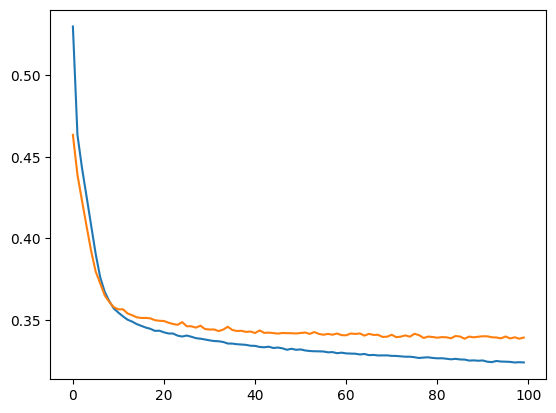

In [51]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

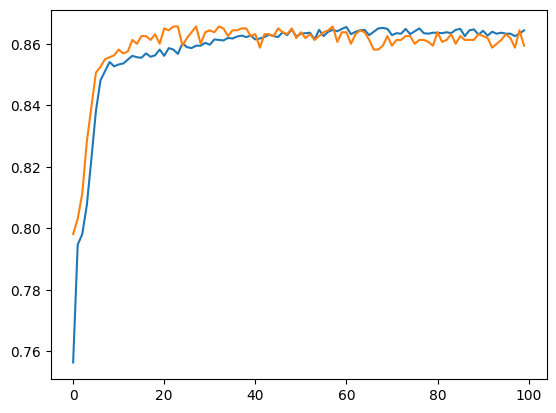

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])